# Trustpilot Review Analysis

This notebook loads scraped Trustpilot reviews from Excel, explores the text, and prepares the data for segmentation with scikit-learn and fuzzy methods.

In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [ ]:
data_path = Path("../../data/trustpilot_reviews.xlsx")

if not data_path.exists():
    raise FileNotFoundError(f"Could not find {data_path}. Run the scraper first.")

df = pd.read_excel(data_path)

# Basic cleaning for robust downstream plotting
if "Review" in df.columns:
    df["Review"] = df["Review"].fillna("").astype(str)
if "Rating" in df.columns:
    df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

df.head()

In [13]:
print("DataFrame shape:", df.shape)
print("\nColumn names and types:")
print(df.dtypes)
print("\nAll columns:", df.columns.tolist())

DataFrame shape: (200, 6)

Column names and types:
ID        int64
Author      str
Title       str
Rating    int64
Date        str
Review      str
dtype: object

All columns: ['ID', 'Author', 'Title', 'Rating', 'Date', 'Review']


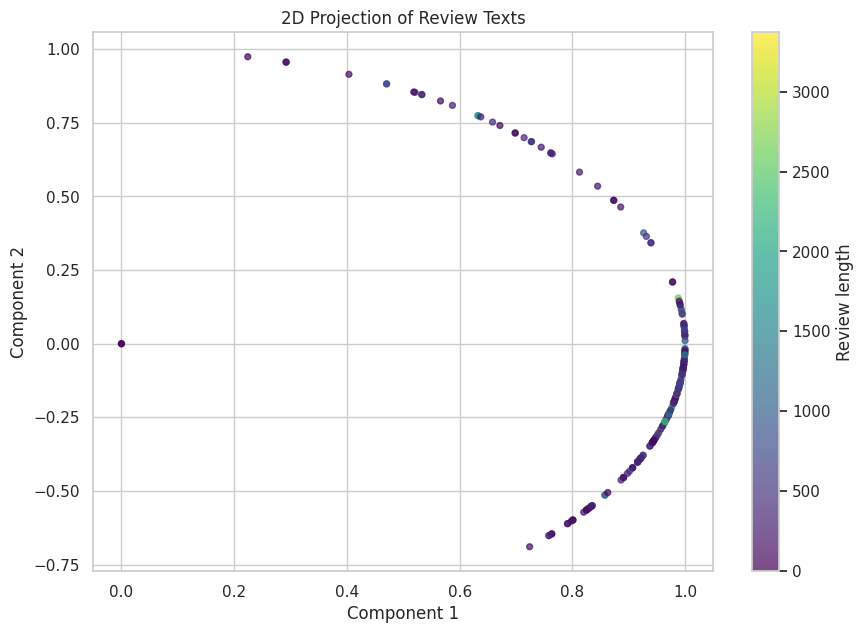

In [14]:
vectorizer = TfidfVectorizer(stop_words="english", max_features=1000)
tfidf_matrix = vectorizer.fit_transform(df["Review"])

svd = TruncatedSVD(n_components=2, random_state=42)
normalizer = Normalizer(copy=False)
lsa = make_pipeline(svd, normalizer)
embedding_2d = lsa.fit_transform(tfidf_matrix)

plt.figure(figsize=(10, 7))
plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], s=18, alpha=0.7, c=df["Review"].str.len(), cmap="viridis")
plt.colorbar(label="Review length")
plt.title("2D Projection of Review Texts")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

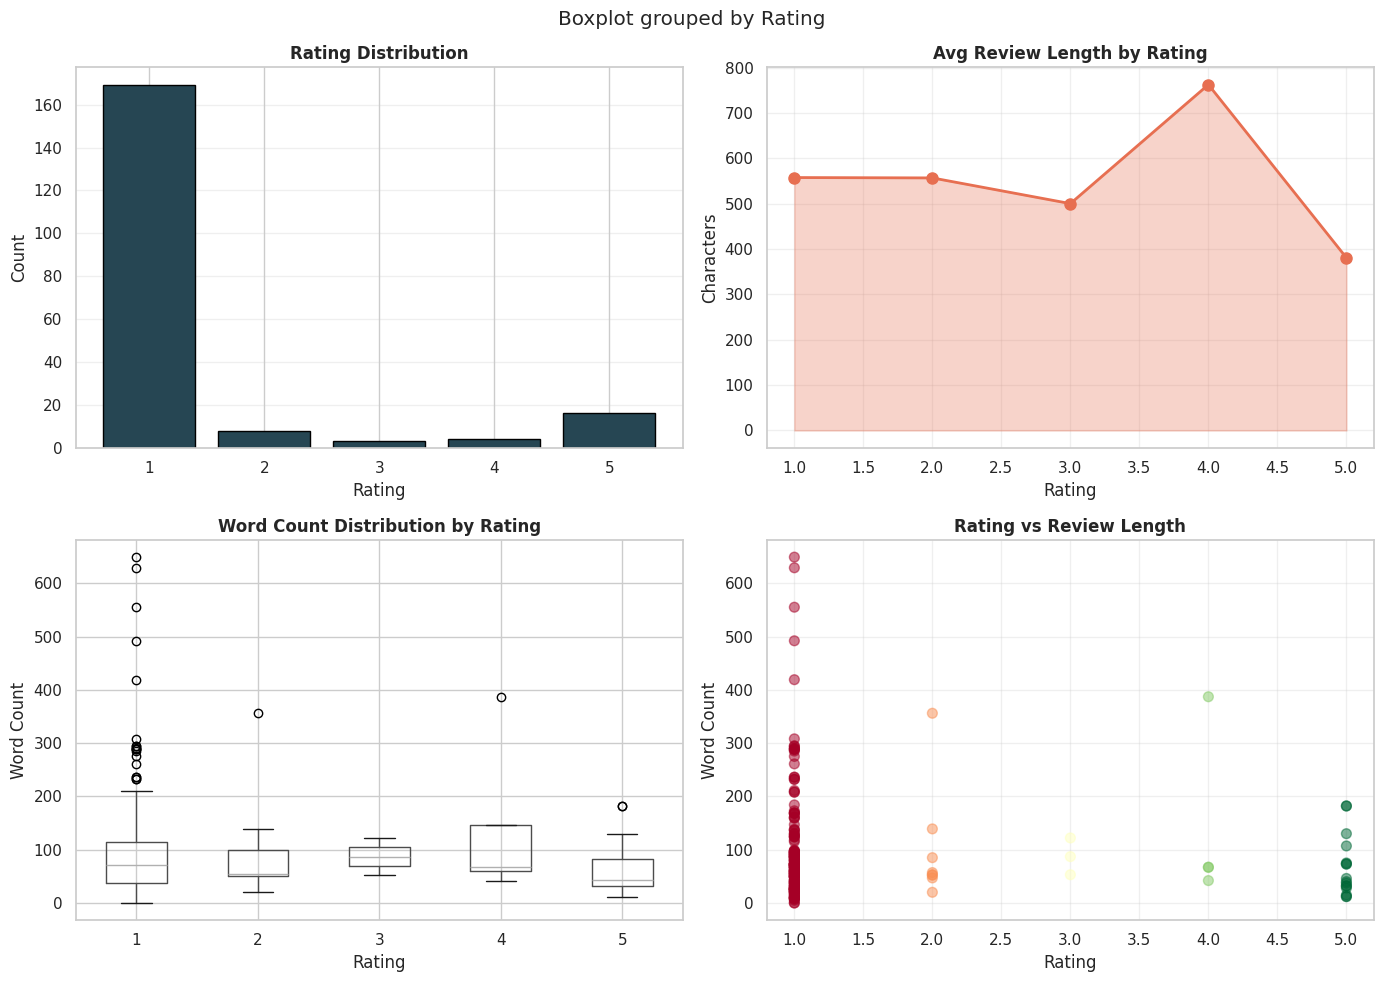


📊 Rating Statistics:
  Average Rating: 1.45
  Median Rating: 1
  Std Dev: 1.17


In [15]:
# ===== RATING ANALYSIS =====
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Rating distribution (bar chart)
rating_counts = df["Rating"].value_counts().sort_index()
axes[0, 0].bar(rating_counts.index, rating_counts.values, color="#264653", edgecolor="black")
axes[0, 0].set_title("Rating Distribution", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Rating")
axes[0, 0].set_ylabel("Count")
axes[0, 0].grid(axis="y", alpha=0.3)

# 2. Average review length by rating
df["review_length"] = df["Review"].str.len()
df["word_count"] = df["Review"].str.split().str.len()
length_by_rating = df.groupby("Rating")["review_length"].mean()
axes[0, 1].plot(length_by_rating.index, length_by_rating.values, marker="o", linewidth=2, markersize=8, color="#e76f51")
axes[0, 1].fill_between(length_by_rating.index, length_by_rating.values, alpha=0.3, color="#e76f51")
axes[0, 1].set_title("Avg Review Length by Rating", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel("Rating")
axes[0, 1].set_ylabel("Characters")
axes[0, 1].grid(alpha=0.3)

# 3. Word count distribution by rating
df.boxplot(column="word_count", by="Rating", ax=axes[1, 0])
axes[1, 0].set_title("Word Count Distribution by Rating", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Rating")
axes[1, 0].set_ylabel("Word Count")
plt.sca(axes[1, 0])
plt.xticks(rotation=0)

# 4. Review sentiment proxy: length vs rating
axes[1, 1].scatter(df["Rating"], df["word_count"], alpha=0.5, s=50, c=df["Rating"], cmap="RdYlGn")
axes[1, 1].set_title("Rating vs Review Length", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Rating")
axes[1, 1].set_ylabel("Word Count")
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Rating Statistics:")
print(f"  Average Rating: {df['Rating'].mean():.2f}")
print(f"  Median Rating: {df['Rating'].median():.0f}")
print(f"  Std Dev: {df['Rating'].std():.2f}")


Valid dates used: 200 / 200
Dropped invalid/unrealistic dates: 0


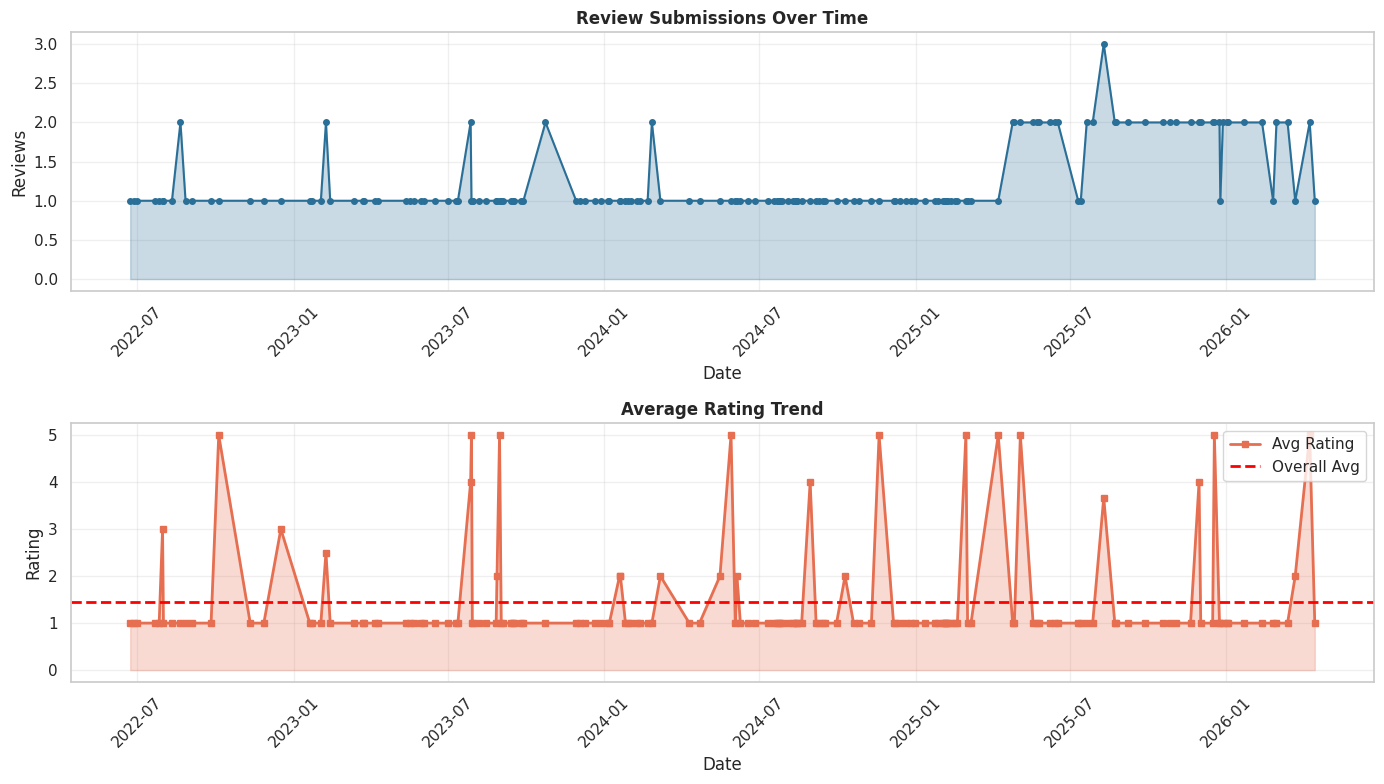

In [16]:
# ===== TEMPORAL ANALYSIS =====
# Parse dates robustly and remove unrealistic dates (e.g., 1900 artifacts from Excel)
raw_date = df["Date"].copy()

# First pass: parse ISO/common formats (year-month-day)
parsed_date = pd.to_datetime(raw_date, errors="coerce")

# Second pass: fallback for unresolved day-first formats
unparsed_mask = parsed_date.isna() & raw_date.notna()
if unparsed_mask.any():
    parsed_date.loc[unparsed_mask] = pd.to_datetime(
        raw_date.loc[unparsed_mask], errors="coerce", dayfirst=True
    )

# Third pass for true numeric Excel serial dates only
numeric_excel_mask = raw_date.apply(
    lambda x: isinstance(x, (int, float)) and not pd.isna(x)
)
if numeric_excel_mask.any():
    parsed_date.loc[numeric_excel_mask] = pd.to_datetime(
        raw_date.loc[numeric_excel_mask].astype(float),
        unit="D",
        origin="1899-12-30",
        errors="coerce",
    )

# Keep only plausible Trustpilot review dates
min_valid_date = pd.Timestamp("2007-01-01")
max_valid_date = pd.Timestamp.today().normalize() + pd.Timedelta(days=1)
valid_mask = parsed_date.between(min_valid_date, max_valid_date, inclusive="both")

df["Date_parsed"] = parsed_date
df_dated = df.loc[valid_mask].copy()

print(f"Valid dates used: {len(df_dated)} / {len(df)}")
print(f"Dropped invalid/unrealistic dates: {len(df) - len(df_dated)}")

if len(df_dated) > 0:
    df_dated = df_dated.sort_values("Date_parsed")

    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    # Reviews over time
    reviews_per_day = df_dated.groupby(df_dated["Date_parsed"].dt.date).size()
    x_reviews = pd.to_datetime(reviews_per_day.index)
    axes[0].plot(x_reviews, reviews_per_day.values, marker="o", linewidth=1.5, markersize=4, color="#2a6f97")
    axes[0].fill_between(x_reviews, reviews_per_day.values, alpha=0.25, color="#2a6f97")
    axes[0].set_title("Review Submissions Over Time", fontsize=12, fontweight="bold")
    axes[0].set_xlabel("Date")
    axes[0].set_ylabel("Reviews")
    axes[0].grid(alpha=0.3)
    plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

    # Average rating trend
    avg_rating_over_time = df_dated.groupby(df_dated["Date_parsed"].dt.date)["Rating"].mean()
    x_rating = pd.to_datetime(avg_rating_over_time.index)
    axes[1].plot(x_rating, avg_rating_over_time.values, marker="s", linewidth=2, markersize=5, color="#e76f51", label="Avg Rating")
    axes[1].fill_between(x_rating, avg_rating_over_time.values, alpha=0.25, color="#e76f51")
    axes[1].axhline(df["Rating"].mean(), color="red", linestyle="--", label="Overall Avg", linewidth=2)
    axes[1].set_title("Average Rating Trend", fontsize=12, fontweight="bold")
    axes[1].set_xlabel("Date")
    axes[1].set_ylabel("Rating")
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

    plt.tight_layout()
    plt.show()
else:
    print("No valid dates after parsing/filtering. Check Date column format.")

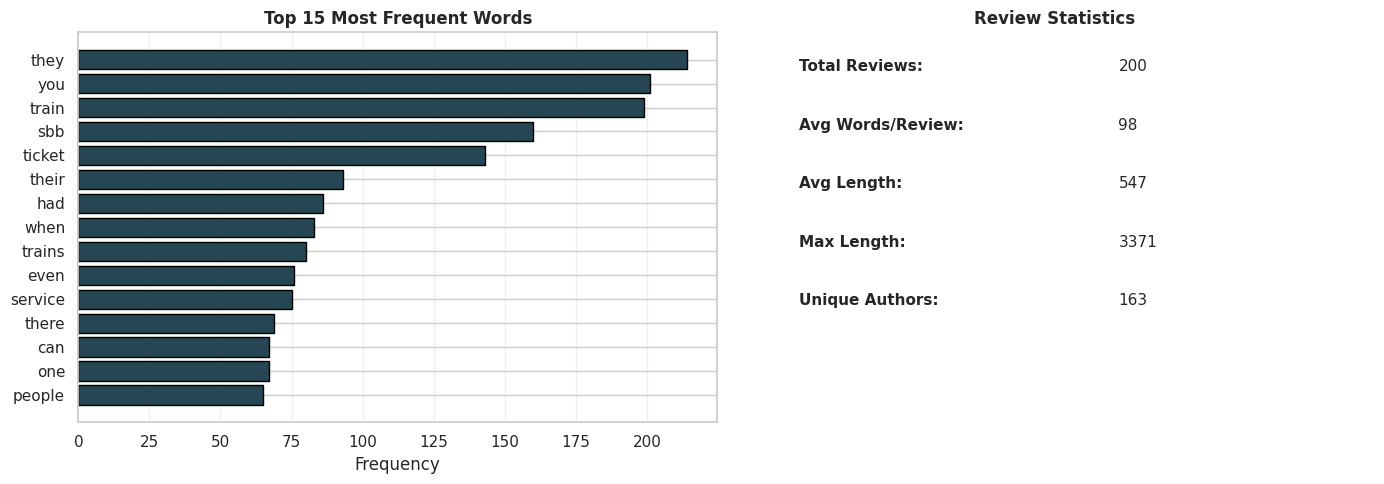

In [17]:
# ===== TEXT ANALYSIS: TOP WORDS & TERMS =====
from collections import Counter
import re

# Extract top terms from all reviews
all_text = " ".join(df["Review"].fillna("").str.lower())
# Remove special characters and split
words = re.findall(r"\b[a-z]{3,}\b", all_text)
stop_words = set(['the', 'and', 'that', 'this', 'have', 'with', 'from', 'but', 'for', 'was', 'are', 'been', 'very', 'good', 'bad', 'not', 'just'])
words = [w for w in words if w not in stop_words]

top_words = Counter(words).most_common(15)
terms, counts = zip(*top_words)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 15 words
axes[0].barh(range(len(terms)), counts, color="#264653", edgecolor="black")
axes[0].set_yticks(range(len(terms)))
axes[0].set_yticklabels(terms)
axes[0].invert_yaxis()
axes[0].set_title("Top 15 Most Frequent Words", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Frequency")
axes[0].grid(axis="x", alpha=0.3)

# Review stats
stats = {
    "Total Reviews": len(df),
    "Avg Words/Review": df["word_count"].mean(),
    "Avg Length": df["review_length"].mean(),
    "Max Length": df["review_length"].max(),
    "Unique Authors": df["Author"].nunique() if "Author" in df.columns else "N/A"
}

axes[1].axis("off")
y_pos = 0.9
for label, value in stats.items():
    if isinstance(value, (int, float)):
        axes[1].text(0.1, y_pos, f"{label}:", fontsize=11, fontweight="bold")
        axes[1].text(0.6, y_pos, f"{value:.0f}" if isinstance(value, float) else str(value), fontsize=11)
    else:
        axes[1].text(0.1, y_pos, f"{label}:", fontsize=11, fontweight="bold")
        axes[1].text(0.6, y_pos, str(value), fontsize=11)
    y_pos -= 0.15

axes[1].set_title("Review Statistics", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

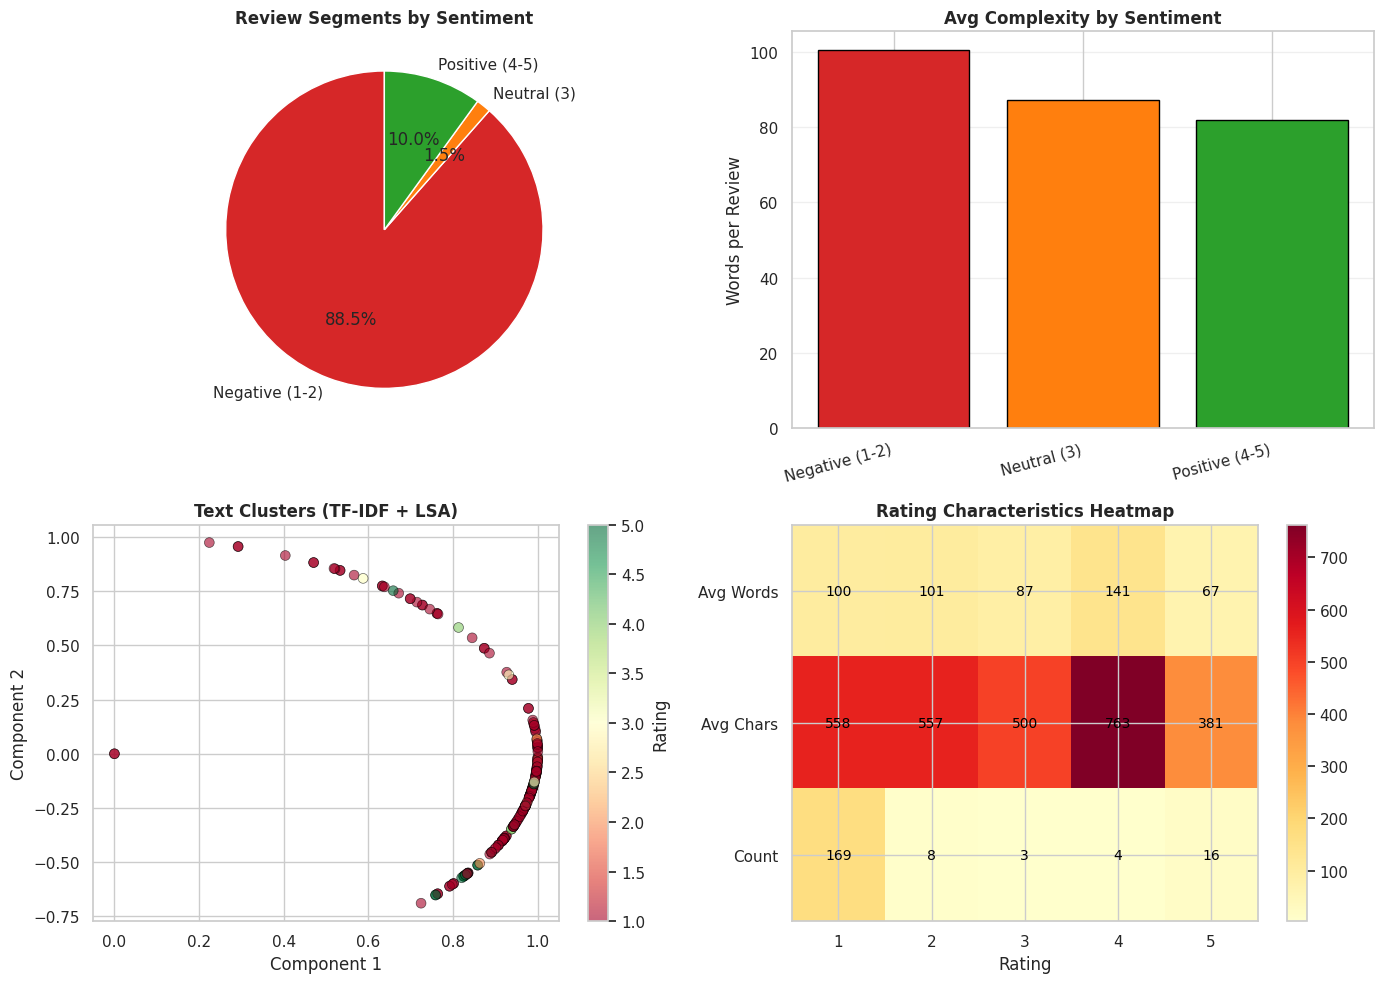


🎯 Segment Summary:

Negative (1-2):
  Count: 177
  Avg Words: 100.5
  Avg Chars: 558

Neutral (3):
  Count: 3
  Avg Words: 87.3
  Avg Chars: 500

Positive (4-5):
  Count: 20
  Avg Words: 82.0
  Avg Chars: 457


In [18]:
# ===== ADVANCED: RATING SEGMENTS & TEXT CLUSTERING PREVIEW =====
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Rating segments summary
rating_segments = {
    "Negative (1-2)": df[df["Rating"] <= 2],
    "Neutral (3)": df[df["Rating"] == 3],
    "Positive (4-5)": df[df["Rating"] >= 4]
}

segment_sizes = [len(v) for v in rating_segments.values()]
segment_labels = list(rating_segments.keys())
colors_pie = ["#d62728", "#ff7f0e", "#2ca02c"]

axes[0, 0].pie(segment_sizes, labels=segment_labels, autopct="%1.1f%%", colors=colors_pie, startangle=90)
axes[0, 0].set_title("Review Segments by Sentiment", fontsize=12, fontweight="bold")

# 2. Text complexity by sentiment
complexity_by_segment = [v["word_count"].mean() for v in rating_segments.values()]
axes[0, 1].bar(segment_labels, complexity_by_segment, color=colors_pie, edgecolor="black")
axes[0, 1].set_title("Avg Complexity by Sentiment", fontsize=12, fontweight="bold")
axes[0, 1].set_ylabel("Words per Review")
axes[0, 1].grid(axis="y", alpha=0.3)
plt.setp(axes[0, 1].xaxis.get_majorticklabels(), rotation=15, ha="right")

# 3. 2D text embedding colored by rating (using existing embedding_2d)
if 'embedding_2d' in globals():
    scatter = axes[1, 0].scatter(embedding_2d[:, 0], embedding_2d[:, 1], 
                                 c=df["Rating"], cmap="RdYlGn", s=50, alpha=0.6, edgecolors="black", linewidth=0.5)
    axes[1, 0].set_title("Text Clusters (TF-IDF + LSA)", fontsize=12, fontweight="bold")
    axes[1, 0].set_xlabel("Component 1")
    axes[1, 0].set_ylabel("Component 2")
    cbar = plt.colorbar(scatter, ax=axes[1, 0])
    cbar.set_label("Rating")

# 4. Heatmap: rating distribution statistics
rating_stats = df.groupby("Rating").agg({
    "word_count": "mean",
    "review_length": "mean",
    "ID": "count"
}).round(1)
rating_stats.columns = ["Avg Words", "Avg Chars", "Count"]

im = axes[1, 1].imshow(rating_stats.T, cmap="YlOrRd", aspect="auto")
axes[1, 1].set_xticks(range(len(rating_stats)))
axes[1, 1].set_xticklabels(rating_stats.index.astype(int))
axes[1, 1].set_yticks(range(len(rating_stats.columns)))
axes[1, 1].set_yticklabels(rating_stats.columns)
axes[1, 1].set_title("Rating Characteristics Heatmap", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Rating")

# Add values to heatmap
for i in range(len(rating_stats.columns)):
    for j in range(len(rating_stats)):
        axes[1, 1].text(j, i, f"{rating_stats.iloc[j, i]:.0f}", ha="center", va="center", color="black", fontsize=10)

plt.colorbar(im, ax=axes[1, 1])
plt.tight_layout()
plt.show()

print("\n🎯 Segment Summary:")
for seg_name, seg_df in rating_segments.items():
    print(f"\n{seg_name}:")
    print(f"  Count: {len(seg_df)}")
    print(f"  Avg Words: {seg_df['word_count'].mean():.1f}")
    print(f"  Avg Chars: {seg_df['review_length'].mean():.0f}")

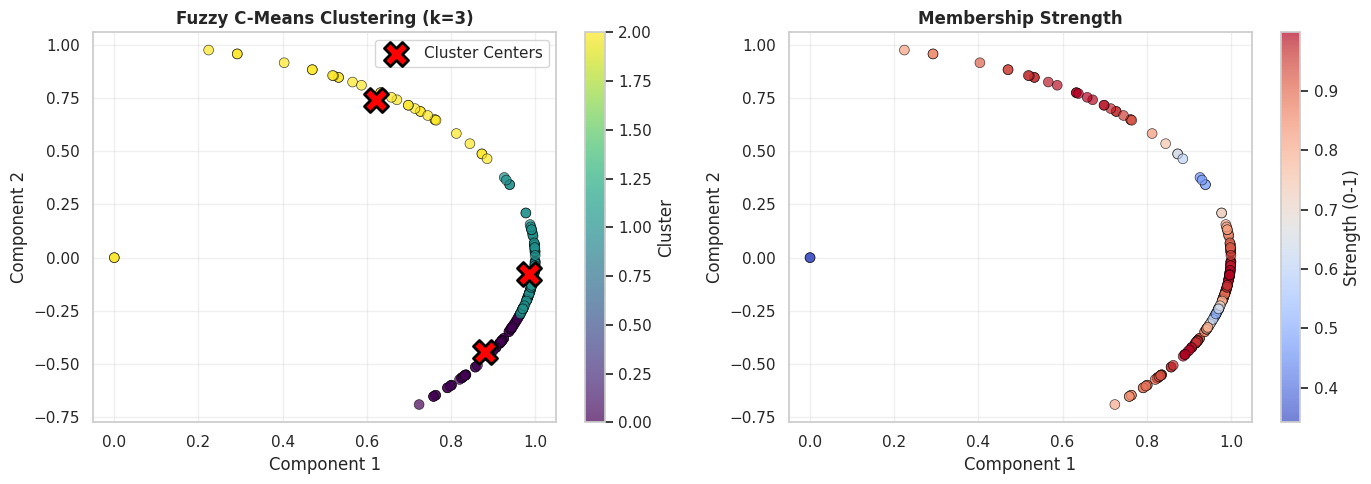


🔀 Fuzzy Clustering Results:
  Fuzziness Performance Index: 0.802
  Partition Coefficient: 0.802
  Cluster sizes: [ 65 102  33]

  Strong assignments: 156 reviews
  Ambiguous assignments: 38 reviews


In [19]:
# ===== FUZZY CLUSTERING: INITIAL SEGMENTATION =====
import skfuzzy as fuzz

# Use the 2D embedding for fuzzy clustering
if 'embedding_2d' in globals() and len(embedding_2d) > 10:
    # Fuzzy C-means with 3 clusters (negative, neutral, positive)
    cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
        embedding_2d.T, 
        c=3,  # 3 clusters
        m=2,  # fuzziness parameter
        error=0.005,
        maxiter=100
    )
    
    # Get cluster membership (which cluster each point belongs to)
    cluster_labels = np.argmax(u, axis=0)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Fuzzy clusters with membership
    scatter1 = axes[0].scatter(embedding_2d[:, 0], embedding_2d[:, 1], 
                               c=cluster_labels, cmap="viridis", s=50, alpha=0.7, edgecolors="black", linewidth=0.5)
    axes[0].scatter(cntr[:, 0], cntr[:, 1], c="red", marker="X", s=300, edgecolors="black", linewidth=2, label="Cluster Centers")
    axes[0].set_title("Fuzzy C-Means Clustering (k=3)", fontsize=12, fontweight="bold")
    axes[0].set_xlabel("Component 1")
    axes[0].set_ylabel("Component 2")
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    cbar1 = plt.colorbar(scatter1, ax=axes[0])
    cbar1.set_label("Cluster")
    
    # Plot 2: Fuzzy membership strength
    max_membership = np.max(u, axis=0)
    scatter2 = axes[1].scatter(embedding_2d[:, 0], embedding_2d[:, 1], 
                               c=max_membership, cmap="coolwarm", s=50, alpha=0.7, edgecolors="black", linewidth=0.5)
    axes[1].set_title("Membership Strength", fontsize=12, fontweight="bold")
    axes[1].set_xlabel("Component 1")
    axes[1].set_ylabel("Component 2")
    axes[1].grid(alpha=0.3)
    cbar2 = plt.colorbar(scatter2, ax=axes[1])
    cbar2.set_label("Strength (0-1)")
    
    plt.tight_layout()
    plt.show()
    
    print("\n🔀 Fuzzy Clustering Results:")
    print(f"  Fuzziness Performance Index: {fpc:.3f}")
    print(f"  Partition Coefficient: {fpc:.3f}")
    print(f"  Cluster sizes: {np.bincount(cluster_labels)}")
    print(f"\n  Strong assignments: {(max_membership > 0.8).sum()} reviews")
    print(f"  Ambiguous assignments: {((max_membership > 0.5) & (max_membership <= 0.8)).sum()} reviews")
else:
    print("⚠️ Embedding not available. Run TF-IDF clustering cell first.")

In [ ]:
# ===== DUPLICATES ANALYSIS: SAME AUTHOR + SAME REVIEW =====
work_df = df.copy()
work_df["Author"] = work_df["Author"].fillna("").astype(str).str.strip()
work_df["Review"] = work_df["Review"].fillna("").astype(str).str.strip()

# 1) Rows where BOTH author and review text are repeated
same_author_same_review = work_df[
    work_df.duplicated(subset=["Author", "Review"], keep=False)
].sort_values(["Author", "Review", "ID"])

print("Rows with same Author + same Review:", len(same_author_same_review))
if len(same_author_same_review) > 0:
    display_cols = [c for c in ["ID", "Author", "Date", "Rating", "Review"] if c in same_author_same_review.columns]
    display(same_author_same_review[display_cols].head(30))
else:
    print("No exact duplicates found for Author + Review.")

# 2) Analysis for repeated authors (regardless of review text)
author_counts = (
    work_df.groupby("Author", dropna=False)
    .agg(
        review_count=("ID", "count"),
        avg_rating=("Rating", "mean"),
        unique_reviews=("Review", "nunique")
    )
    .sort_values("review_count", ascending=False)
)

repeated_authors = author_counts[author_counts["review_count"] > 1].copy()

print("\nAuthors appearing more than once:", len(repeated_authors))
if len(repeated_authors) > 0:
    display(repeated_authors.head(20))

    top_n = min(15, len(repeated_authors))
    top_authors = repeated_authors.head(top_n)

    plt.figure(figsize=(12, 6))
    plt.barh(top_authors.index.astype(str), top_authors["review_count"], color="#1f6f8b")
    plt.gca().invert_yaxis()
    plt.title("Top Repeated Authors by Number of Reviews", fontsize=12, fontweight="bold")
    plt.xlabel("Number of Reviews")
    plt.ylabel("Author")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No repeated authors found.")